# Household Energy Consumption Forecasting
Machine Learning Fundamentals - Practical Skills Assessment

Dataset: Individual household electric power consumption (UCI Machine Learning Repository)

## 1. Import libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_style('whitegrid')
os.makedirs('figures', exist_ok=True)

## 2. Load the dataset

In [2]:
data = pd.read_csv('data/household_power_consumption.txt', sep=';', na_values='?', low_memory=False)
data.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 142.5 MB


In [4]:
print('Rows and columns:', data.shape)

Rows and columns: (2075259, 9)


## 3. Data preprocessing
### 3.1 Missing values and duplicates

In [5]:
data.isna().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [6]:
print('Percentage of missing rows:', round(data['Global_active_power'].isna().mean() * 100, 2), '%')
print('Duplicate rows:', data.duplicated().sum())

Percentage of missing rows: 1.25 %


Duplicate rows: 0


### 3.2 Date-time index

In [7]:
data['datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d/%m/%Y %H:%M:%S')
data = data.drop(columns=['Date', 'Time']).set_index('datetime').sort_index()
print('Duplicate timestamps:', data.index.duplicated().sum())
print('Start:', data.index.min(), ' End:', data.index.max())
data.head()

Duplicate timestamps: 0
Start: 2006-12-16 17:24:00  End: 2010-11-26 21:02:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


### 3.3 How long are the missing gaps?

In [8]:
missing = data['Global_active_power'].isna()
gap_id = (missing != missing.shift()).cumsum()[missing]
gap_sizes = gap_id.value_counts()
print('Number of gaps:', len(gap_sizes))
print('Longest gap (minutes):', gap_sizes.max())
print('Gaps longer than 60 minutes:', (gap_sizes > 60).sum())
print('Missing rows inside the long gaps:', gap_sizes[gap_sizes > 60].sum())

Number of gaps: 71
Longest gap (minutes): 7226
Gaps longer than 60 minutes: 9
Missing rows inside the long gaps: 25691


### 3.4 Filling the missing values
Short gaps (up to 60 minutes) are filled with time interpolation. Long gaps are filled with the value of the same minute one week before.

In [9]:
data = data.interpolate(method='time', limit=60)
for i in range(1, 4):
    data = data.fillna(data.shift(freq=pd.Timedelta(days=7 * i)))
print(data.isna().sum())

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


### 3.5 Resampling to hourly averages

In [10]:
hourly = data.resample('h').mean()
hourly = hourly.iloc[1:-1]   # first and last hour are not complete
print(hourly.shape)
hourly.head()

(34587, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667
2006-12-16 22:00:00,2.200133,0.056167,238.760000,9.523333,0.0,0.133333,4.433333


### 3.6 Feature engineering

In [11]:
df = hourly[['Global_active_power']].copy()
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

df['lag_1'] = df['Global_active_power'].shift(1)
df['lag_24'] = df['Global_active_power'].shift(24)
df['lag_168'] = df['Global_active_power'].shift(168)
df['rolling_mean_24'] = df['Global_active_power'].shift(1).rolling(24).mean()

df = df.dropna()
print(df.shape)
df.head()

(34419, 9)


,Global_active_power,hour,day_of_week,month,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24
datetime,,,,,,,,,
2006-12-23 18:00:00,3.879400,18,5,12,1,5.452533,2.686967,3.632200,3.099713
2006-12-23 19:00:00,4.117833,19,5,12,1,3.879400,3.938167,3.400233,3.149397
2006-12-23 20:00:00,4.181400,20,5,12,1,4.117833,3.536067,3.268567,3.156883
2006-12-23 21:00:00,3.288433,21,5,12,1,4.181400,4.548667,3.056467,3.183772
2006-12-23 22:00:00,4.327933,22,5,12,1,3.288433,3.065067,2.200133,3.131263


## 4. Exploratory Data Analysis

In [12]:
hourly.describe().round(3)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,34587.000,34587.000,34587.000,34587.000,34587.000,34587.000,34587.000
mean,1.089,0.124,240.846,4.617,1.121,1.296,6.453
std,0.896,0.067,2.995,3.752,3.538,4.185,7.345
min,0.124,0.001,225.834,0.503,0.000,0.000,0.000
25%,0.341,0.078,239.200,1.510,0.000,0.000,0.650
50%,0.799,0.107,240.985,3.407,0.000,0.333,1.650
75%,1.577,0.149,242.693,6.593,0.000,0.650,14.167
max,6.561,0.774,251.902,28.383,48.367,46.433,21.550


In [13]:
hourly.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 34587 entries, 2006-12-16 18:00:00 to 2010-11-26 20:00:00
Freq: h
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_active_power    34587 non-null  float64
 1   Global_reactive_power  34587 non-null  float64
 2   Voltage                34587 non-null  float64
 3   Global_intensity       34587 non-null  float64
 4   Sub_metering_1         34587 non-null  float64
 5   Sub_metering_2         34587 non-null  float64
 6   Sub_metering_3         34587 non-null  float64
dtypes: float64(7)
memory usage: 2.1 MB


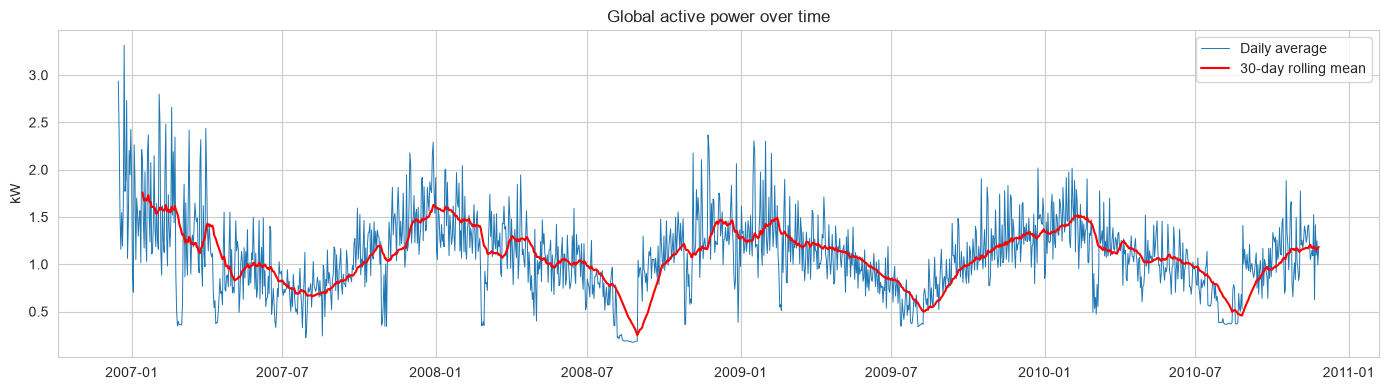

In [14]:
daily = hourly['Global_active_power'].resample('D').mean()
plt.figure(figsize=(14, 4))
plt.plot(daily, linewidth=0.7, label='Daily average')
plt.plot(daily.rolling(30).mean(), color='red', label='30-day rolling mean')
plt.title('Global active power over time')
plt.ylabel('kW'); plt.legend()
plt.tight_layout(); plt.savefig('figures/fig_lineplot.png', dpi=150); plt.show()

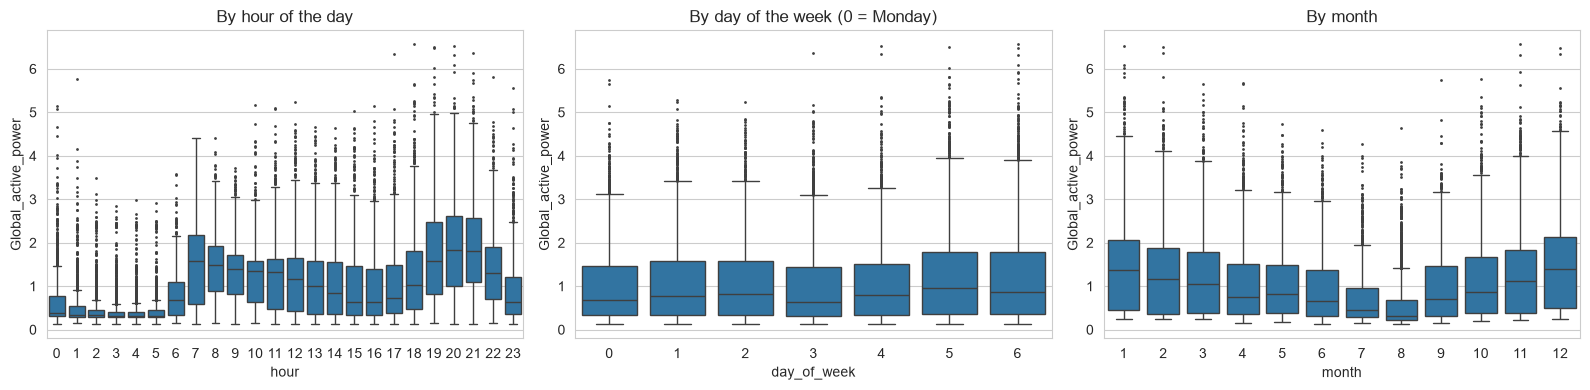

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(x=df['hour'], y=df['Global_active_power'], ax=axes[0], fliersize=1)
axes[0].set_title('By hour of the day')
sns.boxplot(x=df['day_of_week'], y=df['Global_active_power'], ax=axes[1], fliersize=1)
axes[1].set_title('By day of the week (0 = Monday)')
sns.boxplot(x=df['month'], y=df['Global_active_power'], ax=axes[2], fliersize=1)
axes[2].set_title('By month')
plt.tight_layout(); plt.savefig('figures/fig_boxplots.png', dpi=150); plt.show()

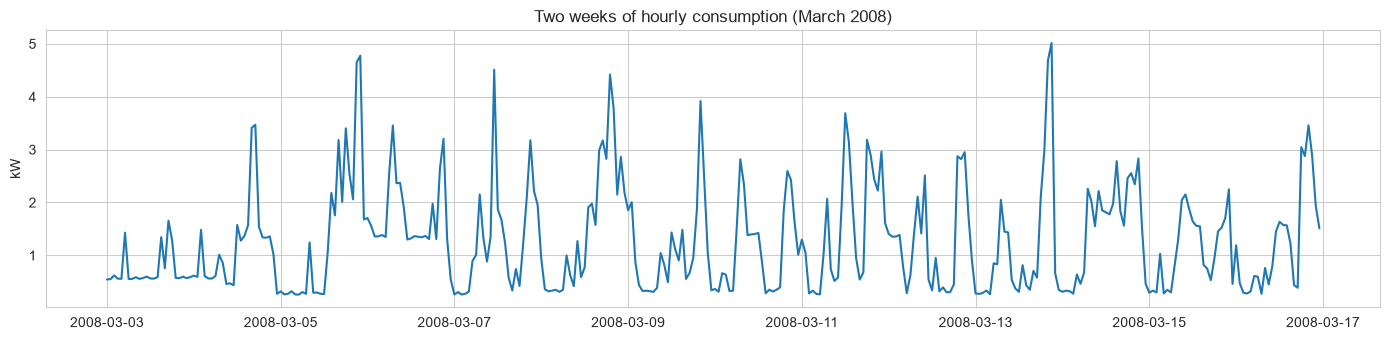

In [16]:
week = hourly['Global_active_power']['2008-03-03':'2008-03-16']
plt.figure(figsize=(14, 3.5))
plt.plot(week)
plt.title('Two weeks of hourly consumption (March 2008)')
plt.ylabel('kW')
plt.tight_layout(); plt.savefig('figures/fig_twoweeks.png', dpi=150); plt.show()

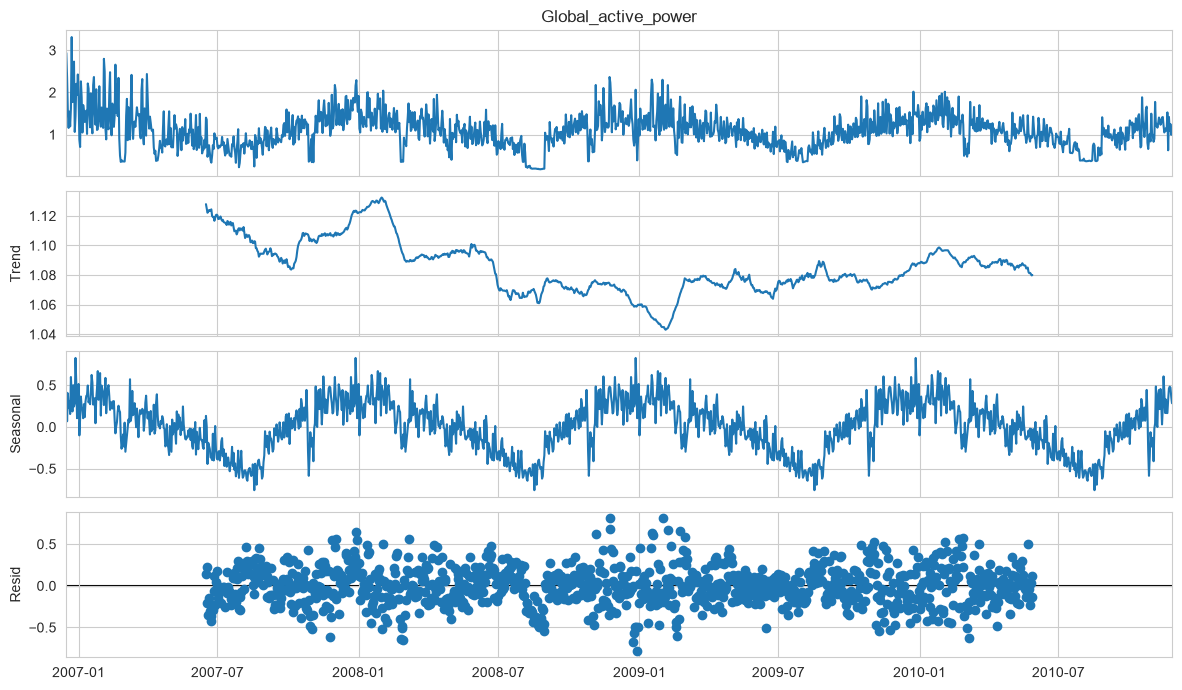

In [17]:
result = seasonal_decompose(daily, model='additive', period=365)
fig = result.plot()
fig.set_size_inches(12, 7)
plt.tight_layout(); plt.savefig('figures/fig_decompose.png', dpi=150); plt.show()

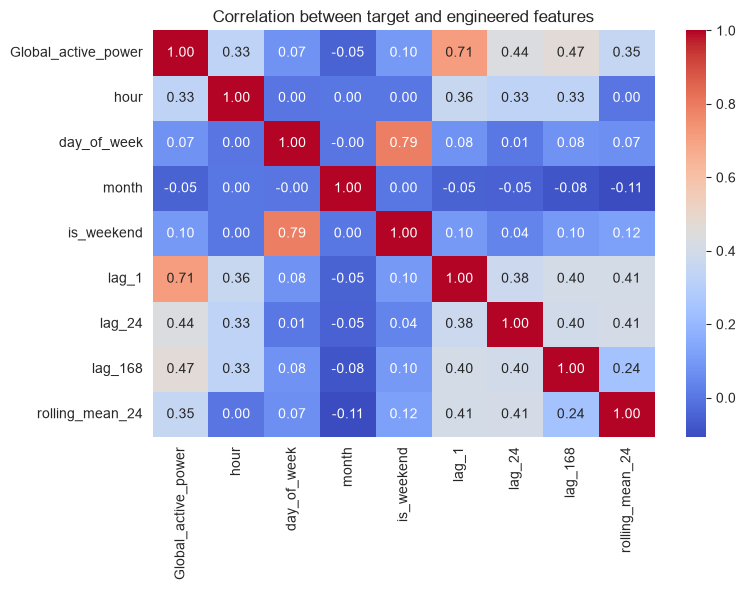

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation between target and engineered features')
plt.tight_layout(); plt.savefig('figures/fig_heatmap.png', dpi=150); plt.show()

## 5. Chronological train / test split

In [20]:
split = int(len(df) * 0.8)
train = df.iloc[:split]
test = df.iloc[split:]

features = ['hour', 'day_of_week', 'month', 'is_weekend', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24']
target = 'Global_active_power'
X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

print('Train:', train.index.min(), 'to', train.index.max(), '->', len(train), 'rows')
print('Test :', test.index.min(), 'to', test.index.max(), '->', len(test), 'rows')

Train: 2006-12-23 18:00:00 to 2010-02-13 00:00:00 -> 27535 rows
Test : 2010-02-13 01:00:00 to 2010-11-26 20:00:00 -> 6884 rows


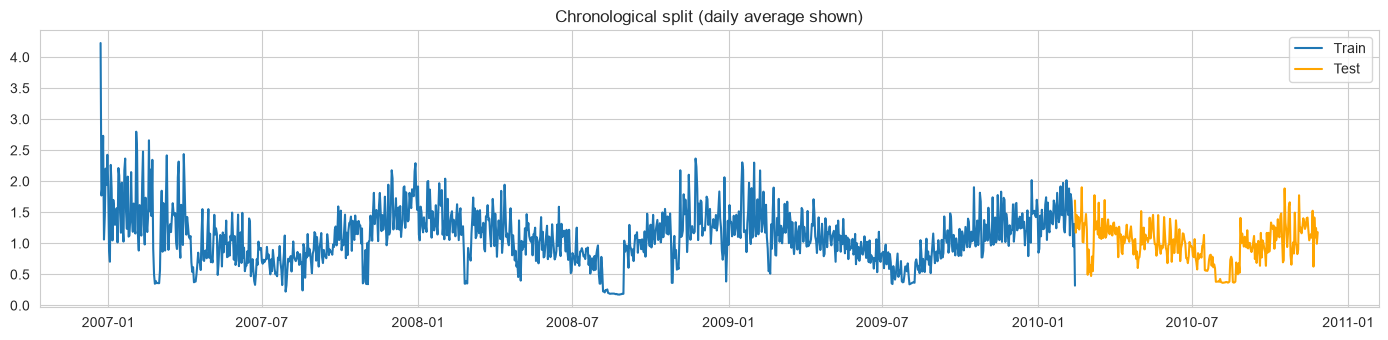

In [21]:
plt.figure(figsize=(14, 3.5))
plt.plot(train[target].resample('D').mean(), label='Train')
plt.plot(test[target].resample('D').mean(), color='orange', label='Test')
plt.title('Chronological split (daily average shown)')
plt.legend(); plt.tight_layout(); plt.savefig('figures/fig_split.png', dpi=150); plt.show()

## 6. Models
All models predict the next hour (one-step-ahead forecast).

In [22]:
results = {}
predictions = {}

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    results[name] = [mae, rmse, r2]
    predictions[name] = pd.Series(np.asarray(y_pred), index=y_true.index)
    print(name, '-> MAE:', round(mae, 4), ' RMSE:', round(rmse, 4), ' R2:', round(r2, 4))

### 6.0 Naive baseline (the next hour is the same as the last hour)

In [23]:
evaluate('Naive (persistence)', y_test, X_test['lag_1'])

Naive (persistence) -> MAE: 0.391  RMSE: 0.5965  R2: 0.3424


### 6.1 SARIMA (classical statistical model)
The model is fitted on the last 180 days of the training set to keep the training time reasonable. After that, the fitted parameters are kept fixed and the model walks through the test set one hour at a time.

In [24]:
sarima_train = y_train.iloc[-24 * 180:].asfreq('h')
sarima = SARIMAX(sarima_train, order=(1, 0, 1), seasonal_order=(1, 1, 1, 24))
sarima_fit = sarima.fit(disp=False)
print(sarima_fit.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6041      0.017     35.517      0.000       0.571       0.637
ma.L1         -0.0254      0.022     -1.149      0.251      -0.069       0.018
ar.S.L24      -0.0159      0.013     -1.184      0.236      -0.042       0.010
ma.S.L24      -0.9521      0.005   -206.963      0.000      -0.961      -0.943
sigma2         0.3092      0.004     71.908      0.000       0.301       0.318


In [25]:
sarima_test = sarima_fit.append(y_test.asfreq('h'), refit=False)
sarima_pred = sarima_test.predict(start=y_test.index[0], end=y_test.index[-1])
evaluate('SARIMA', y_test, sarima_pred)

SARIMA -> MAE: 0.3511  RMSE: 0.4964  R2: 0.5446


### 6.2 Linear Regression

In [26]:
lr = LinearRegression()
lr.fit(X_train, y_train)
evaluate('Linear Regression', y_test, lr.predict(X_test))

Linear Regression -> MAE: 0.3648  RMSE: 0.5143  R2: 0.5112


### 6.3 Random Forest

In [27]:
rf = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=5, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
evaluate('Random Forest', y_test, rf.predict(X_test))

Random Forest -> MAE: 0.3311  RMSE: 0.4807  R2: 0.5729


### 6.4 XGBoost

In [28]:
xgb = XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=5, subsample=0.8,
                   colsample_bytree=0.8, random_state=42)
xgb.fit(X_train, y_train)
evaluate('XGBoost', y_test, xgb.predict(X_test))

XGBoost -> MAE: 0.3287  RMSE: 0.4744  R2: 0.584


## 7. Model evaluation and comparison

In [29]:
results_df = pd.DataFrame(results, index=['MAE', 'RMSE', 'R2']).T.round(4)
results_df.to_csv('results.csv')
results_df

,MAE,RMSE,R2
Naive (persistence),0.3910,0.5965,0.3424
SARIMA,0.3511,0.4964,0.5446
Linear Regression,0.3648,0.5143,0.5112
Random Forest,0.3311,0.4807,0.5729
XGBoost,0.3287,0.4744,0.5840


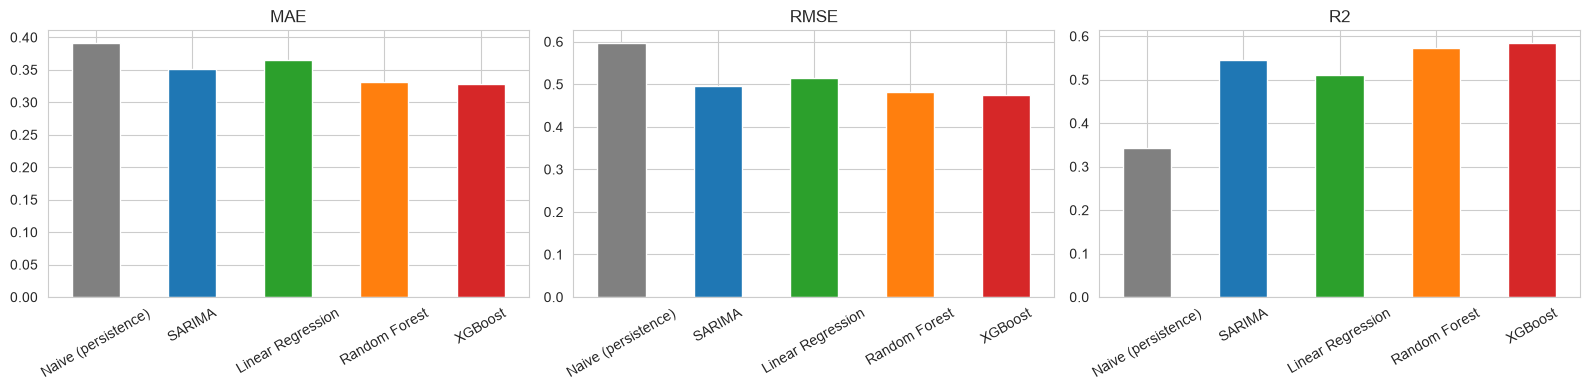

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    results_df[metric].plot(kind='bar', ax=ax, color=['grey', 'tab:blue', 'tab:green', 'tab:orange', 'tab:red'])
    ax.set_title(metric); ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig('figures/fig_metrics.png', dpi=150); plt.show()

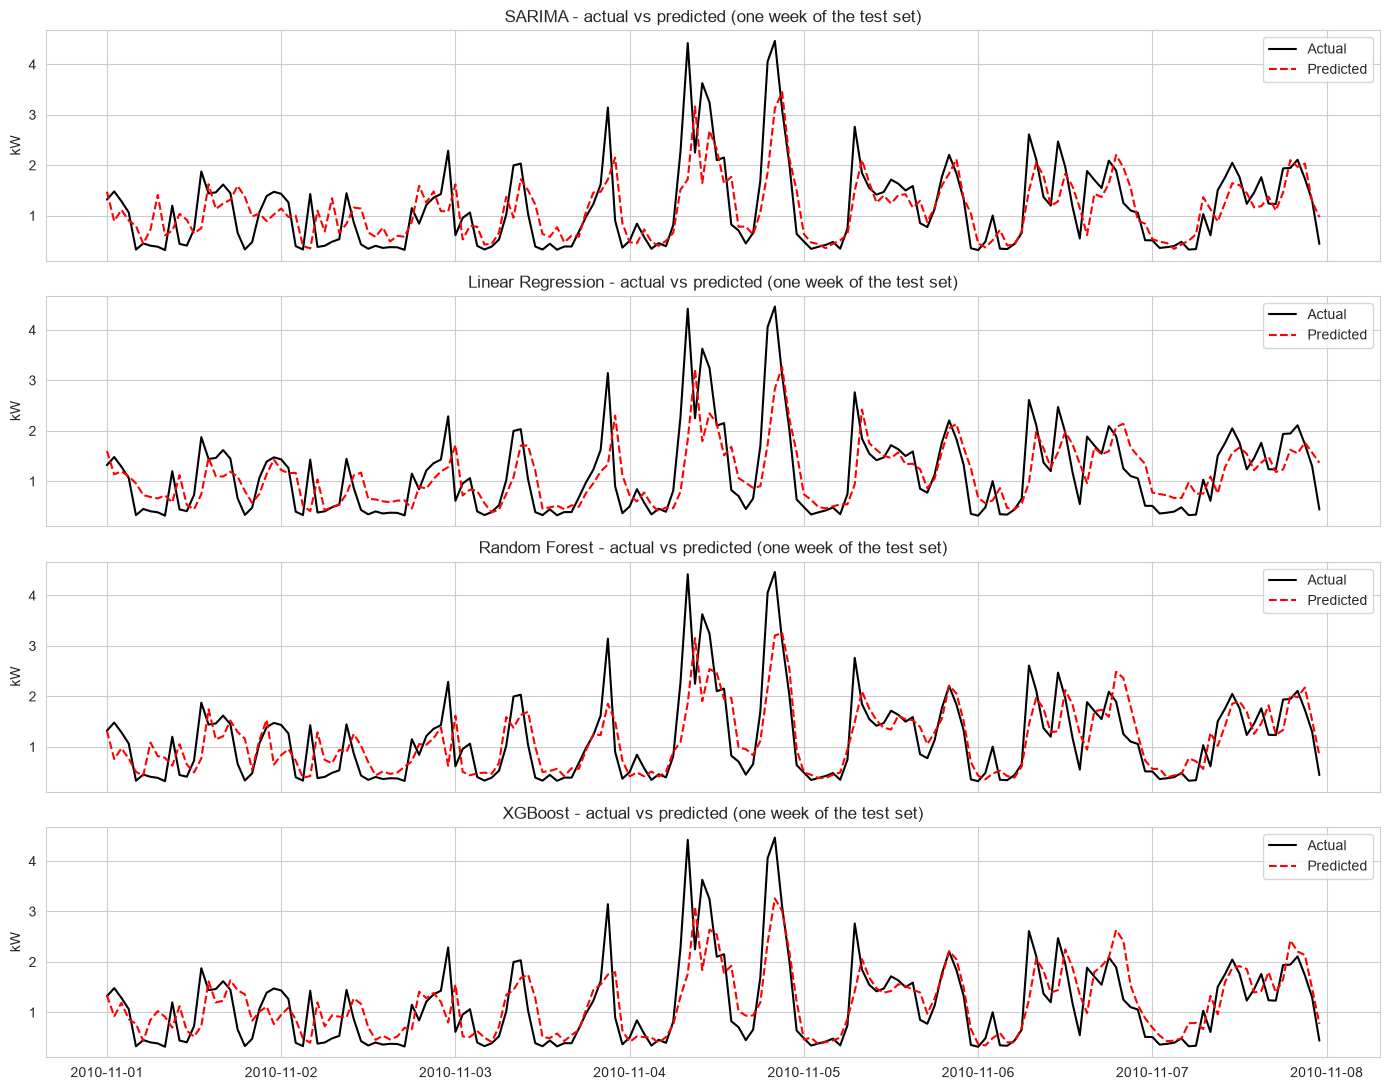

In [31]:
start, end = '2010-11-01', '2010-11-07'
models = ['SARIMA', 'Linear Regression', 'Random Forest', 'XGBoost']
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
for ax, name in zip(axes, models):
    ax.plot(y_test[start:end], label='Actual', color='black')
    ax.plot(predictions[name][start:end], label='Predicted', color='red', linestyle='--')
    ax.set_title(name + ' - actual vs predicted (one week of the test set)')
    ax.set_ylabel('kW'); ax.legend(loc='upper right')
plt.tight_layout(); plt.savefig('figures/fig_actual_vs_pred.png', dpi=150); plt.show()

Best model: XGBoost


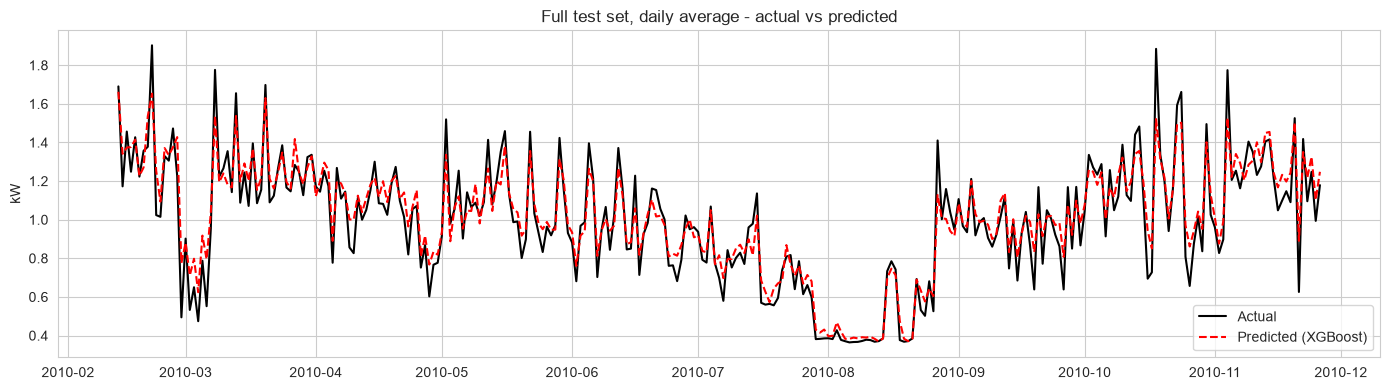

In [32]:
best = results_df.drop('Naive (persistence)')['RMSE'].idxmin()
print('Best model:', best)
plt.figure(figsize=(14, 4))
plt.plot(y_test.resample('D').mean(), label='Actual', color='black')
plt.plot(predictions[best].resample('D').mean(), label='Predicted (' + best + ')', color='red', linestyle='--')
plt.title('Full test set, daily average - actual vs predicted')
plt.ylabel('kW'); plt.legend()
plt.tight_layout(); plt.savefig('figures/fig_best_full.png', dpi=150); plt.show()

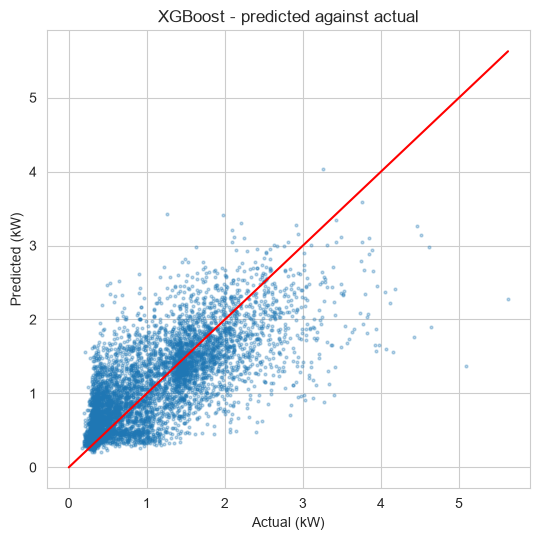

In [33]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test, predictions[best], s=4, alpha=0.3)
plt.plot([0, y_test.max()], [0, y_test.max()], color='red')
plt.xlabel('Actual (kW)'); plt.ylabel('Predicted (kW)')
plt.title(best + ' - predicted against actual')
plt.tight_layout(); plt.savefig('figures/fig_scatter.png', dpi=150); plt.show()

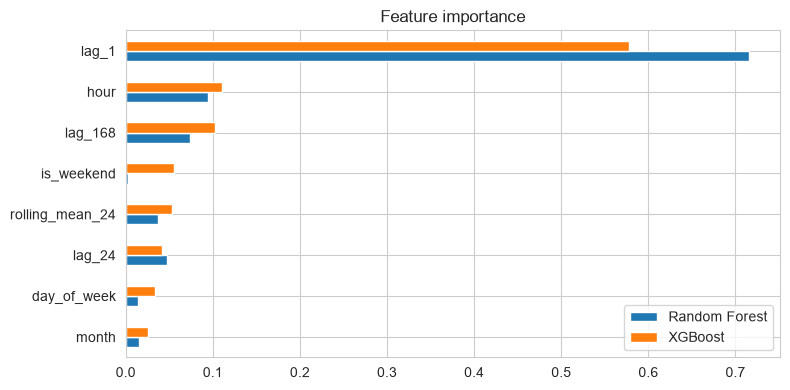

,Random Forest,XGBoost
hour,0.094,0.111
day_of_week,0.014,0.034
month,0.015,0.026
is_weekend,0.003,0.056
lag_1,0.715,0.578
lag_24,0.047,0.041
lag_168,0.073,0.102
rolling_mean_24,0.038,0.053


In [34]:
importance = pd.DataFrame({'Random Forest': rf.feature_importances_, 'XGBoost': xgb.feature_importances_}, index=features)
importance.sort_values('XGBoost').plot(kind='barh', figsize=(8, 4))
plt.title('Feature importance')
plt.tight_layout(); plt.savefig('figures/fig_importance.png', dpi=150); plt.show()
importance.round(3)